# Data Cleaning & Preprocessing: Fast Food Marketing Campaign
---
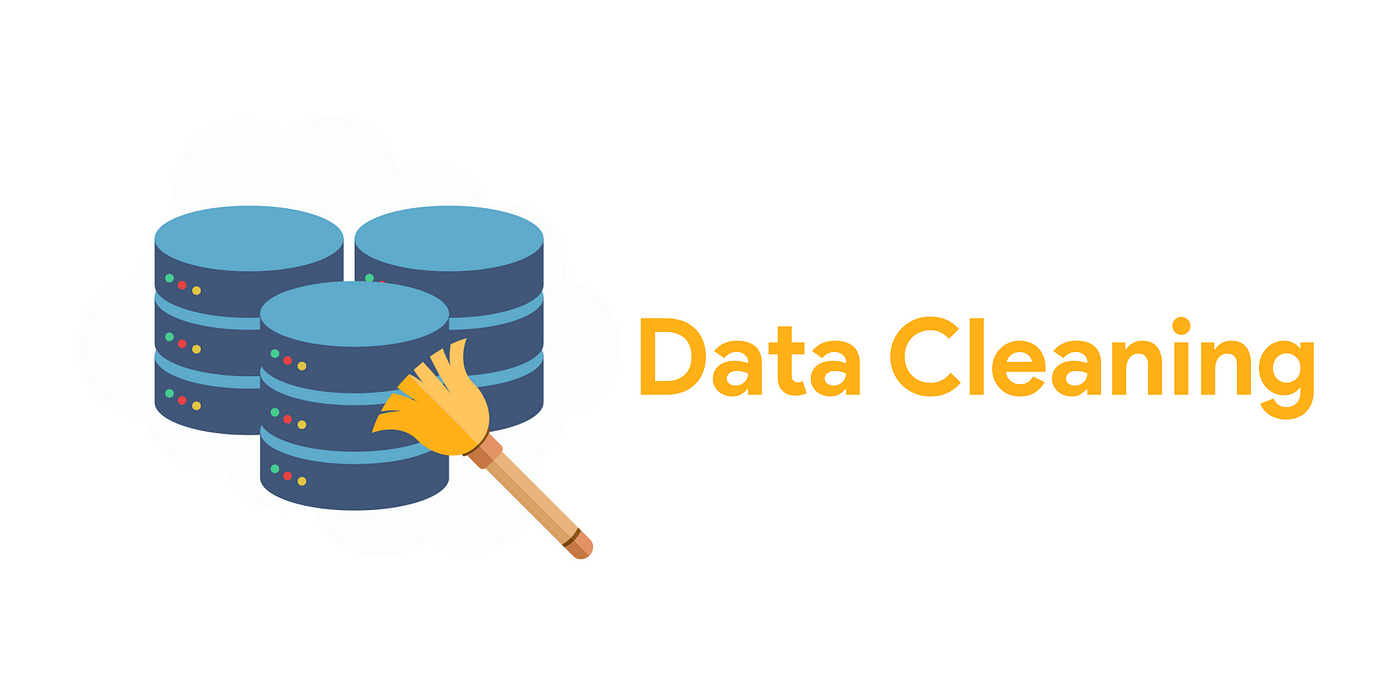 


## introduction:
This analysis aims to evaluate the effectiveness of three different marketing campaigns (Promotion 1, 2, and 3) and determine their impact on sales volume **(SalesInThousands)**. We will embark on a data exploration journey, starting with a thorough analysis and culminating in insights that support informed decision-making.

In [25]:
#impor Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#read the data WA_Marketing_Campaing.csv
raw_data = pd.read_csv('/home/mona/Downloads/SAD/AAI/student/Data Science/project 1: Fast food marketing/data/raw/WA_Marketing-Campaign.csv')


**optional step:** 

to simplify the callback: convert all lowercase column characters using `lower()`

In [27]:
#Convert all column names to lowercase for consistency and easier access
raw_data.columns = raw_data.columns.str.lower()
print(raw_data.columns)

Index(['marketid', 'marketsize', 'locationid', 'ageofstore', 'promotion',
       'week', 'salesinthousands'],
      dtype='object')


To calculate the IQR manually, we use the following formula:
$$IQR = Q3 − Q1$$

The first quartile (**Q1**) is the value located at the **25%** of the sorted data.

The third quartile (**Q3**) is the value located at the **75%** of the sorted data.

The difference between these two values ​​is the IQR.

In [28]:
# 1. Calculating the first and third springs
Q1 = raw_data['salesinthousands'].quantile(0.25)
Q3 = raw_data['salesinthousands'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

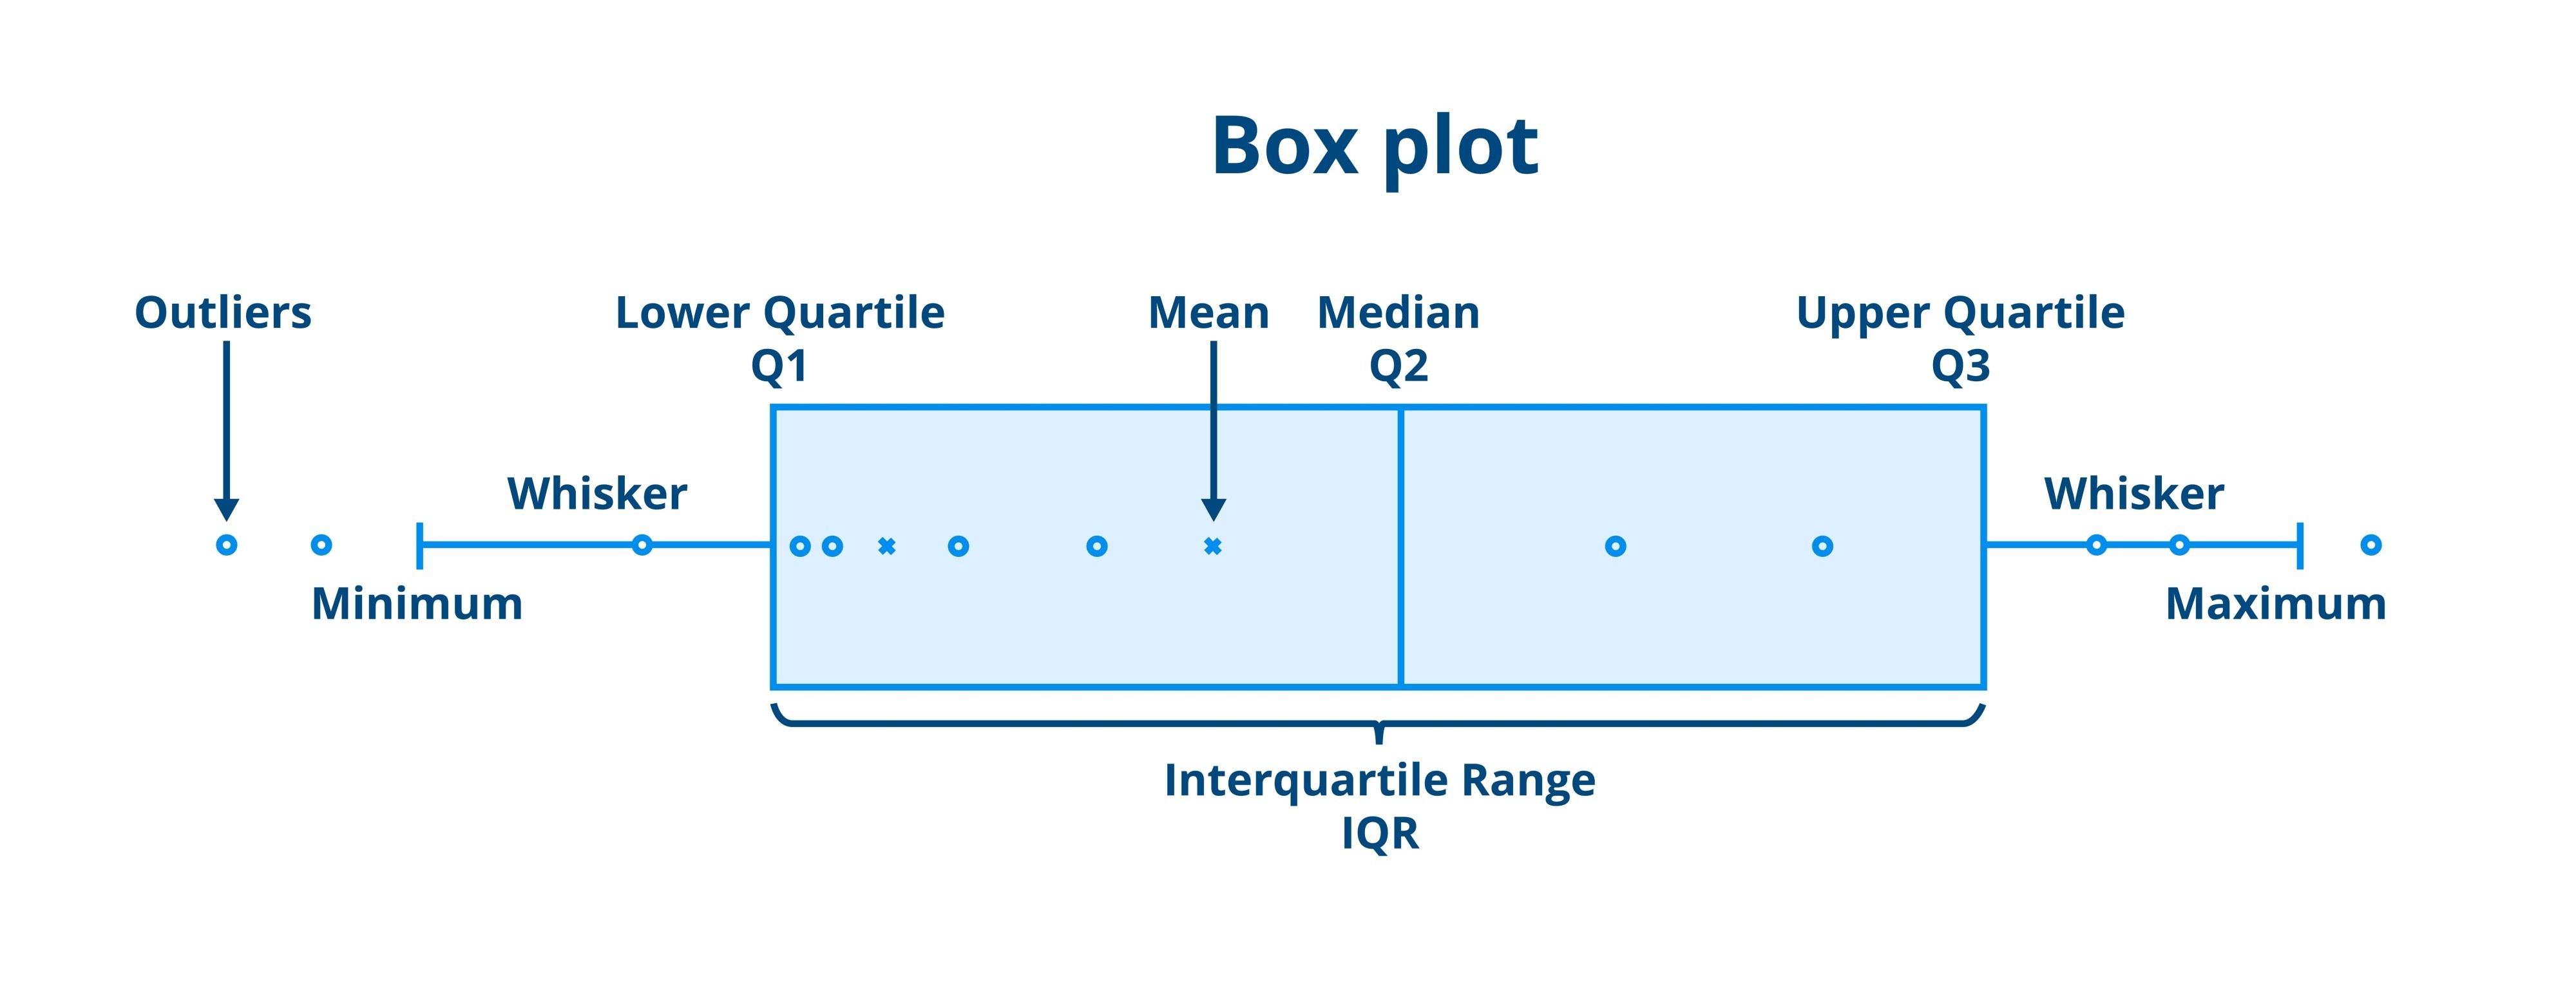

In [29]:
print(f"(Q1): {Q1}")
print(f"(Q3): {Q3}")
print(f"(IQR): {IQR}")

(Q1): 42.545
(Q3): 60.4775
(IQR): 17.932499999999997


In [30]:
# 2. Defining the limits of normal values

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [31]:
clean_data = raw_data[(raw_data['salesinthousands'] >= lower_bound) & 
                      (raw_data['salesinthousands'] <= upper_bound)]

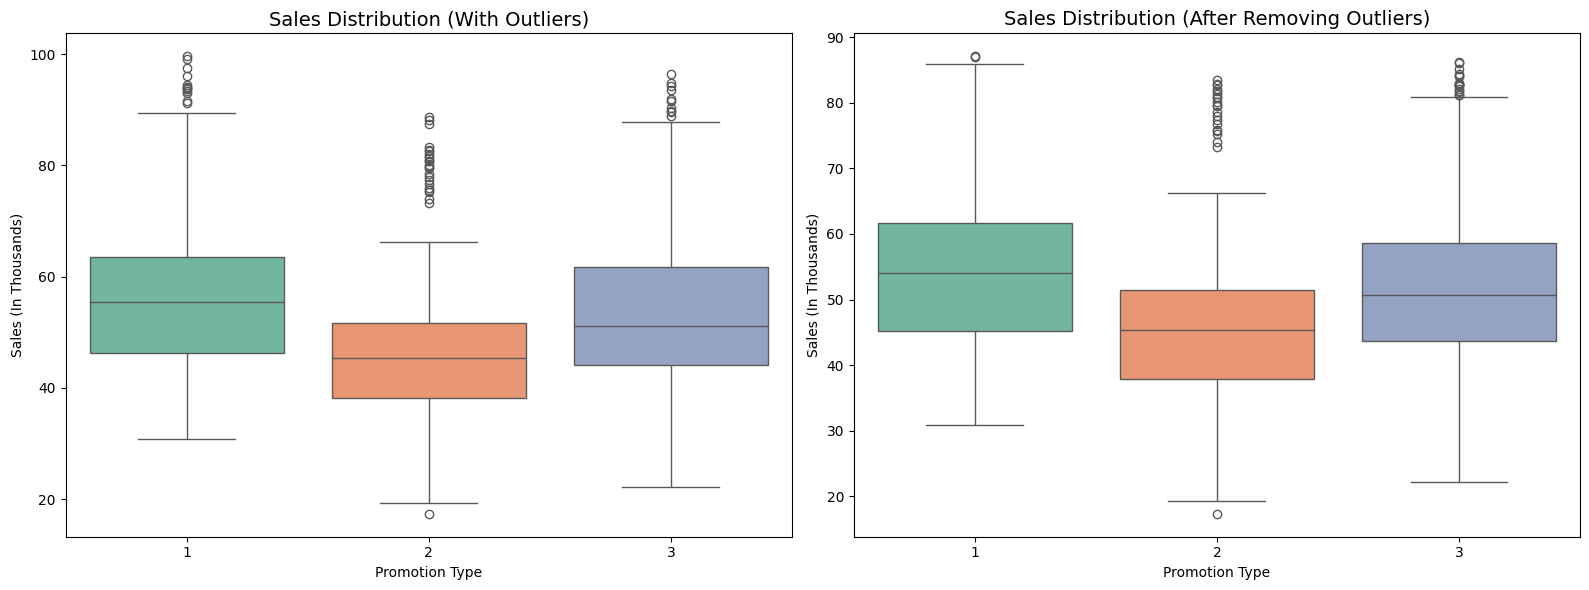

In [32]:
# Preparing the drawing space 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First drawing: Before cleaning (Original)
sns.boxplot(ax=axes[0], data=raw_data, x='promotion', y='salesinthousands', 
            hue='promotion', palette='Set2', legend=False)
axes[0].set_title('Sales Distribution (With Outliers)', fontsize=14)
axes[0].set_xlabel('Promotion Type')
axes[0].set_ylabel('Sales (In Thousands)')

# Second drawing: After cleaning
sns.boxplot(ax=axes[1], data=clean_data, x='promotion', y='salesinthousands', 
            hue='promotion', palette='Set2', legend=False)
axes[1].set_title('Sales Distribution (After Removing Outliers)', fontsize=14)
axes[1].set_xlabel('Promotion Type')
axes[1].set_ylabel('Sales (In Thousands)')


# Coordinating the spacing between the two drawings
plt.tight_layout()
plt.show()


In [33]:
print(f"Original Records: {len(raw_data)}")
print(f"Clean Records: {len(clean_data)}")
print(f"Outliers Removed: {len(raw_data) - len(clean_data)}")

Original Records: 548
Clean Records: 515
Outliers Removed: 33


**Original Records (548):** This is the original sample size you started with.

**Outliers Removed (33):** The code detected 33 data points (approximately 6% of the total data) that were so far from the mean that they might "fool" the statistical calculations. These are the points that appeared as black circles above the box in the first graph.

**Clean Records (515):** This is the new study population extract the final results. It is a more stable and homogeneous population.

## Final step:
save clean data to processed folder.

In [35]:
file_path= '/home/mona/Downloads/SAD/AAI/student/Data Science/project 1: Fast food marketing/data/processed/marketing_cleaned.csv'

clean_data.to_csv(file_path, index=False)
print(f"saved file:{file_path}")

saved file:/home/mona/Downloads/SAD/AAI/student/Data Science/project 1: Fast food marketing/data/processed/marketing_cleaned.csv


---

## Summary: 
After examining the raw data and performing the software cleanup, the following results were obtained:

Methodology: Interquartile Range (IQR) was used to filter out outliers in the sales column.

Data Filtering:

- Original Records: 548

- Outliers: 33 (excluded)

- Approved Data: 515

Save: The cleaned data was exported to the data/processed/ folder to begin the statistical analysis phase.